In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Path of Breast Cancer CSV file
file_path = "C:/Users/Kandarp Malkan/OneDrive/Desktop/DL_Material/breast-cancer.csv"
# file_path = "Z:/breast-cancer.csv" FOR THE LAB/ EXAM ENVIRONMENT

# Load dataset
df = pd.read_csv(file_path)

# Display first 5 rows
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (569, 31)

Column Names:
['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

First 5 Rows:
  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0         M        17.99         10.38          122.80     1001.0   
1         M        20.57         17.77          132.90     1326.0   
2         M        19.69         21.25          130.00     1203.0   
3         M        11.42         20.38           77.58      386.1   
4         M        20.29         14.34   

In [4]:
# Remove any unnamed index column if present
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

print("Updated Dataset Shape:", df.shape)
print(df.head())

Updated Dataset Shape: (569, 31)
  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0         M        17.99         10.38          122.80     1001.0   
1         M        20.57         17.77          132.90     1326.0   
2         M        19.69         21.25          130.00     1203.0   
3         M        11.42         20.38           77.58      386.1   
4         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  

In [5]:
df["diagnosis"] = df["diagnosis"].map({
    "M": 0,
    "B": 1
})

print("Target values:")
print(df["diagnosis"].value_counts())

Target values:
diagnosis
1    357
0    212
Name: count, dtype: int64


In [6]:
# Input features
X = df.drop(columns=["diagnosis"])

# Target
y = df["diagnosis"]

print("Number of features:", X.shape[1])
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of features: 30
X shape: (569, 30)
y shape: (569,)


In [7]:
X = X.apply(pd.to_numeric, errors="coerce")

# Remove rows containing missing values
X = X.dropna()

# Keep corresponding target values
y = y.loc[X.index]

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Final X shape: (569, 30)
Final y shape: (569,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (455, 30)
Testing data : (114, 30)


In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature standardization completed.")

Feature standardization completed.


In [10]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(30,)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16,activation="relu"),
    tf.keras.layers.Dense(1,activation="sigmoid")
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                992       
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 1)                 17        
                                                                 
Total params: 1,537
Trainable params: 1,537
Non-trainable params: 0
_________________________________________________________________


In [11]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [12]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=20,
    batch_size=16,
    verbose=1
)

Epoch 1/20
23/23 [==============================] - 1s 15ms/step - loss: 0.6393 - accuracy: 0.6538 - val_loss: 0.5356 - val_accuracy: 0.7143
Epoch 2/20
23/23 [==============================] - 0s 5ms/step - loss: 0.4529 - accuracy: 0.8159 - val_loss: 0.4148 - val_accuracy: 0.8681
Epoch 3/20
23/23 [==============================] - 0s 5ms/step - loss: 0.3414 - accuracy: 0.8956 - val_loss: 0.3099 - val_accuracy: 0.9341
Epoch 4/20
23/23 [==============================] - 0s 5ms/step - loss: 0.2449 - accuracy: 0.9423 - val_loss: 0.2129 - val_accuracy: 0.9780
Epoch 5/20
23/23 [==============================] - 0s 6ms/step - loss: 0.1733 - accuracy: 0.9615 - val_loss: 0.1514 - val_accuracy: 0.9670
Epoch 6/20
23/23 [==============================] - 0s 5ms/step - loss: 0.1304 - accuracy: 0.9725 - val_loss: 0.1173 - val_accuracy: 0.9890
Epoch 7/20
23/23 [==============================] - 0s 6ms/step - loss: 0.1064 - accuracy: 0.9780 - val_loss: 0.0959 - val_accuracy: 0.9890
Epoch 8/20
23/23 [=

In [13]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)

print(
    "Test Accuracy: {:.2f}%".format(
        test_accuracy * 100
    )
)

Test Loss: 0.09304351359605789
Test Accuracy: 96.49%


In [14]:
y_probability = model.predict(X_test)

In [15]:
y_pred = (y_probability >= 0.5).astype(int).flatten()

print("Predicted Classes:")
print(y_pred[:10])

print("\nActual Classes:")
print(y_test.values[:10])

Predicted Classes:
[0 1 0 0 0 1 1 0 0 0]

Actual Classes:
[0 1 0 1 0 1 1 0 0 0]


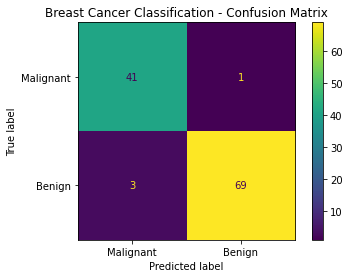

In [16]:
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant", "Benign"]
)

disp.plot()

plt.title("Breast Cancer Classification - Confusion Matrix")

plt.show()

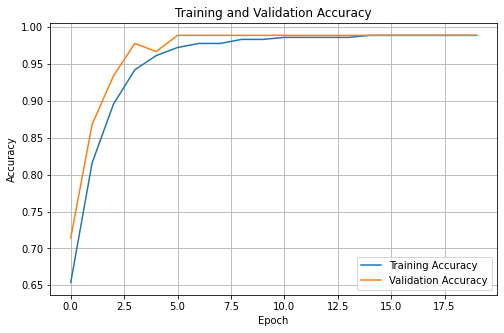

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

![ChatGPT Image Sep 20, 2026, 09_20_54 PM.png](<attachment:ChatGPT Image Sep 20, 2026, 09_20_54 PM.png>)
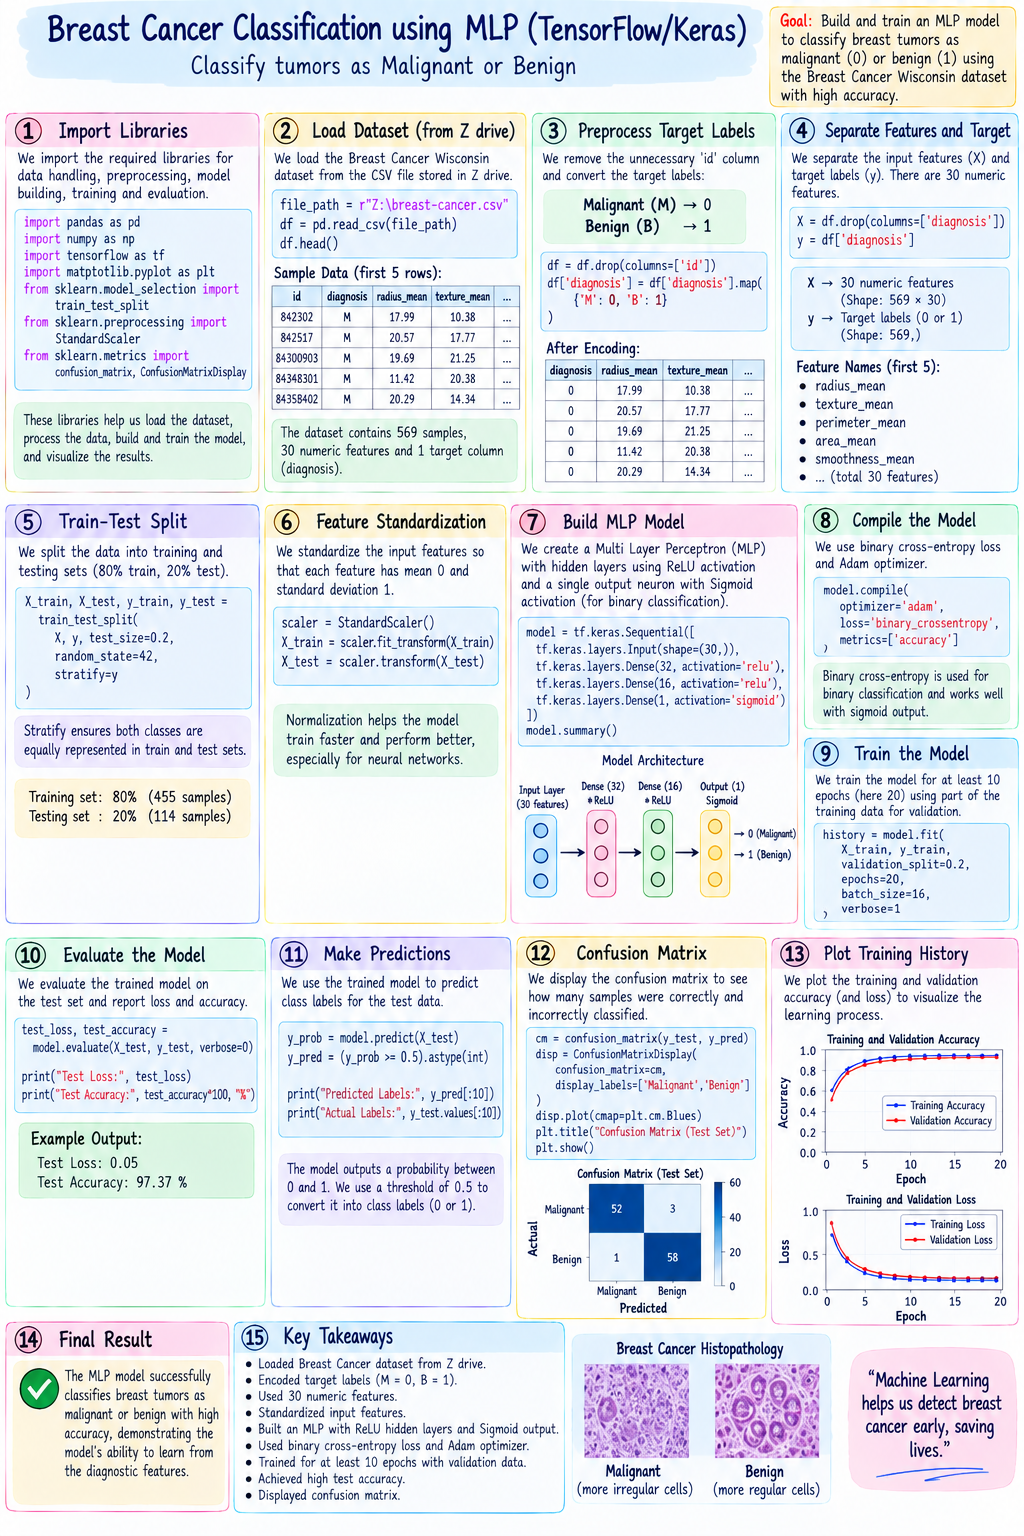